# 로지스틱 회귀 - 타이타닉 생존 여부 예측

In [13]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

## 1. 데이터 로드 및 탐색

In [14]:
# 데이터 로드
df = pd.read_csv(r'pandas/data/titanic_train.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton


In [15]:
# 데이터 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [16]:
# 결측치 확인
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embark_town      2
dtype: int64

In [17]:
# 종속변수(survived) 분포 확인
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## 2. 데이터 전처리

In [18]:
# 결측치 처리
# age: 중앙값으로 대치 (177개 결측)
df['age'] = df['age'].fillna(df['age'].median())

# embark_town: 최빈값으로 대치 (2개 결측)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 결측치 처리 확인
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embark_town    0
dtype: int64

In [19]:
# 범주형 변수 원핫인코딩 (sex, embark_town)
df = pd.get_dummies(df, columns=['sex', 'embark_town'], drop_first=True, dtype='i1')
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## 3. 학습/테스트 분리 및 스케일링

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 독립변수(X)와 종속변수(y) 분리
X = df.drop(columns=['survived'])
y = df['survived']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# 학습/테스트 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

X shape: (891, 8)
y shape: (891,)
Train: (712, 8), Test: (179, 8)


In [21]:
# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train으로 fit + transform
X_test_scaled = scaler.transform(X_test)         # test는 transform만

print(f'Train 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}')

Train 평균: 0.0000, 표준편차: 1.0000


## 4. 로지스틱 회귀 모델 학습 및 예측

### 시그모이드 함수란?

로지스틱 회귀는 내부적으로 **시그모이드(Sigmoid) 함수**를 사용하여 예측값을 0~1 사이의 확률로 변환합니다.

**계산 과정:**

1. 선형 결합 계산: `z = intercept + (pclass × w₁) + (age × w₂) + (sex_male × w₃) + ...`
2. 시그모이드 함수 적용: `σ(z) = 1 / (1 + e^(-z))` → 결과가 0~1 사이의 **확률**이 됨
3. 분류 판단: 확률 ≥ 0.5 → 생존(1), 확률 < 0.5 → 사망(0)

**핵심 특징:**
- z가 **0이면** → σ(z) = 0.5 (반반)
- z가 **양수로 클수록** → σ(z) → 1에 가까움 (생존)
- z가 **음수로 클수록** → σ(z) → 0에 가까움 (사망)

/var/folders/mf/j4fycs613vd1hddkf_1jbwkr0000gn/T/ipykernel_76238/1777657467.py:25: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from current font.
  plt.tight_layout()
/Users/eunbumkim/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


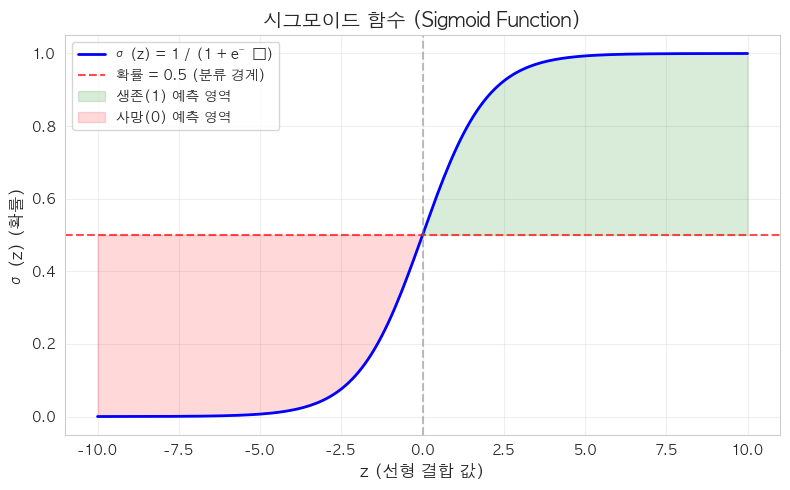

In [22]:
# 시그모이드 함수 그래프
def sigmoid(z):
    """시그모이드 함수: 입력값 z를 0~1 사이의 확률로 변환"""
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), color='blue', linewidth=2, label='σ(z) = 1 / (1 + e⁻ᶻ)')

# 기준선: 확률 0.5 (분류 경계)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='확률 = 0.5 (분류 경계)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 영역 표시
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) >= 0.5), alpha=0.15, color='green', label='생존(1) 예측 영역')
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) < 0.5), alpha=0.15, color='red', label='사망(0) 예측 영역')

plt.xlabel('z (선형 결합 값)', fontsize=12)
plt.ylabel('σ(z) (확률)', fontsize=12)
plt.title('시그모이드 함수 (Sigmoid Function)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 생성 및 학습
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

# 예측
y_pred = lr.predict(X_test_scaled)

# 가중치(계수) 확인
print('=== 가중치(coef) ===')
for col, coef in zip(X_train.columns, lr.coef_[0]):
    print(f'  {col:25s} = {coef:.4f}')
print(f'\n  intercept = {lr.intercept_[0]:.4f}')

=== 가중치(coef) ===
  pclass                    = -0.7853
  age                       = -0.3962
  sibsp                     = -0.3500
  parch                     = -0.0961
  fare                      = 0.1265
  sex_male                  = -1.2771
  embark_town_Queenstown    = -0.0461
  embark_town_Southampton   = -0.1894

  intercept = -0.6752


## 5. 모델 평가

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 정확도(Accuracy)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# 분류 리포트 (Precision, Recall, F1-Score)
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['사망(0)', '생존(1)']))

Accuracy: 0.8101

=== Classification Report ===
              precision    recall  f1-score   support

       사망(0)       0.83      0.86      0.84       105
       생존(1)       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



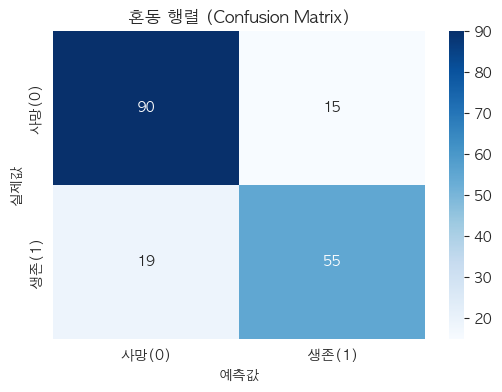

In [25]:
# 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['사망(0)', '생존(1)'],
            yticklabels=['사망(0)', '생존(1)'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('혼동 행렬 (Confusion Matrix)')
plt.show()